# 01 — Trust the evaluation harness

**Milestone 2.** Before tuning anything, demonstrate that the FROZEN evaluation layer (`src/harness/eval_core.py`) is correct and show what it does on the real Last.fm data. Nothing here is a *result* — it is a correctness demonstration of the instrument we will measure with.

Three things:
1. The metrics reproduce the hand-worked toy numbers (the same case asserted in `tests/test_eval_core.py`).
2. The per-user split, on real data, is disjoint, leakage-safe, and keeps a train history for every scored user.
3. A single-user, end-to-end metric walkthrough — what scoring one user will look like in Milestone 3.

Design rationale lives in [`docs/specs/eval_design.md`](../docs/specs/eval_design.md). The split parameters are recorded in [`decisions.md`](../decisions.md).

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import scipy.sparse as sp
from src.data_loading import build_interaction_matrix, load_user_artists
from src.harness import eval_core
from src.harness import make_split as ms  # for the canonical artifact paths only
from src import plotting as viz

viz.set_style()

## 1. The metrics reproduce the hand-worked toy example

Held-out (relevant) items `{0, 2}`; the model's ranked recommendations `[0, 1, 2, 3]`; cutoff `k = 3`. By hand:

- precision@3 = hits / k = 2 / 3
- recall@3 = hits / |relevant| = 2 / 2 = 1.0
- NDCG@3: DCG = 1/log2(2) + 1/log2(4) = 1.5; IDCG = 1/log2(2) + 1/log2(3) = 1.63093; NDCG = 0.91973

In [2]:
rec, rel, k = np.array([0, 1, 2, 3]), {0, 2}, 3
print(f'precision@{k} = {eval_core.precision_at_k(rec, rel, k):.5f}   (expected 0.66667)')
print(f'recall@{k}    = {eval_core.recall_at_k(rec, rel, k):.5f}   (expected 1.00000)')
print(f'NDCG@{k}      = {eval_core.ndcg_at_k(rec, rel, k):.5f}   (expected 0.91973)')

precision@3 = 0.66667   (expected 0.66667)
recall@3    = 1.00000   (expected 1.00000)
NDCG@3      = 0.91972   (expected 0.91973)


These match `tests/test_eval_core.py`, which asserts them to 1e-4. The metrics are trustworthy.

## 2. The per-user split on real data

`per_user_train_test_split` is the building block. Here it is applied once (two-way) to the full matrix, so we can inspect its guarantees directly.

In [3]:
im = build_interaction_matrix(load_user_artists())
split = eval_core.per_user_train_test_split(im.matrix, test_fraction=0.2, seed=0)
train, test = split.train, split.test

# Guarantees:
overlap = train.multiply(test).nnz
reconciles = train.nnz + test.nnz == im.matrix.nnz
tr_counts = np.asarray((train > 0).sum(axis=1)).ravel()
te_counts = np.asarray((test > 0).sum(axis=1)).ravel()
scored = te_counts > 0
every_test_user_has_train = bool((tr_counts[scored] >= 1).all())

print(f'train interactions: {train.nnz:,}   test interactions: {test.nnz:,}')
print(f'disjoint (no cell in both): {overlap == 0}')
print(f'partition reconciles to full matrix: {reconciles}')
print(f'every scored user keeps >=1 train item (leakage-safe): {every_test_user_has_train}')
print(f'users scored on test: {int(scored.sum()):,} / {len(te_counts):,}  '
      f'(the rest are <2-interaction cold-start users, held out of scoring)')

2026-06-30 18:29:14 | INFO    | data_loading | Loaded 92,834 interactions from user_artists.dat


train interactions: 74,265   test interactions: 18,569
disjoint (no cell in both): True
partition reconciles to full matrix: True
every scored user keeps >=1 train item (leakage-safe): True
users scored on test: 1,884 / 1,892  (the rest are <2-interaction cold-start users, held out of scoring)


median train/user: 40   median test/user: 10


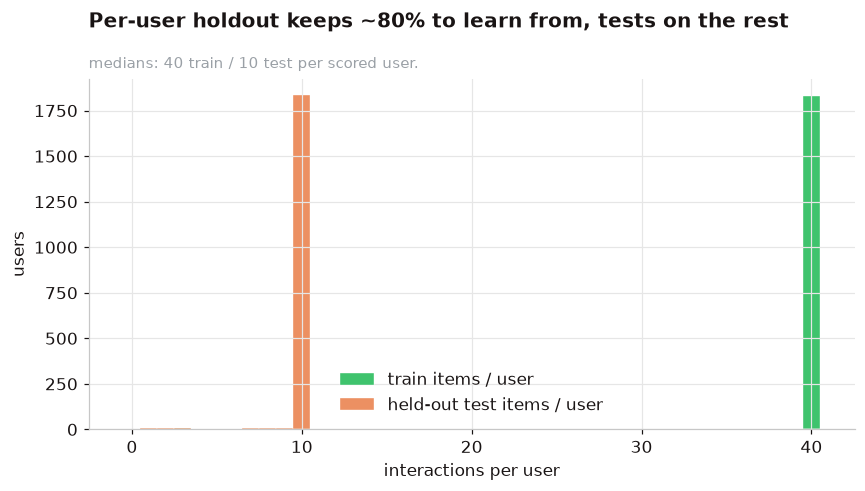

In [4]:
_ = viz.plot_train_test_split(tr_counts[scored], te_counts[scored],
                              save_path=project_root / 'outputs' / 'figures' / 'train_test_split.png')
print(f'median train/user: {np.median(tr_counts[scored]):.0f}   median test/user: {np.median(te_counts[scored]):.0f}')

## 3. The three-way partition (`make_split`) and the locked holdout

`make_split.py` composes the same frozen function **twice**: first it seals a locked holdout (20% per user), then it splits the remainder into the search-visible train/test. The loop reads only `train.npz` / `test.npz`; the locked holdout is sealed behind a path defined only in `make_split.py`, and this notebook deliberately does **not** load it.

In [5]:
if ms.TRAIN_PATH.exists() and ms.TEST_PATH.exists():
    tr = sp.load_npz(ms.TRAIN_PATH)
    te = sp.load_npz(ms.TEST_PATH)
    # We intentionally do NOT load ms.LOCKED_HOLDOUT_PATH. Its size is reported by
    # make_split; we infer it by reconciliation rather than reading its contents.
    holdout_nnz = im.matrix.nnz - tr.nnz - te.nnz
    print('search-visible train interactions:', f'{tr.nnz:,}')
    print('search-visible test interactions: ', f'{te.nnz:,}')
    print('locked holdout interactions (by reconciliation, not read):', f'{holdout_nnz:,}')
    print('reconciles to full matrix:', tr.nnz + te.nnz + holdout_nnz == im.matrix.nnz)
else:
    print('Artifacts not found. Generate them once with:  python -m src.harness.make_split')

search-visible train interactions: 59,411
search-visible test interactions:  14,854
locked holdout interactions (by reconciliation, not read): 18,569
reconciles to full matrix: True


## 4. Single-user metric walkthrough (a preview of Milestone 3)

To make the metrics concrete: take one user, rank all artists by **train-set popularity** (a stand-in for a real model), remove the artists they already have in train, and score the top-10 against their held-out test artists. In Milestone 3 the ranking comes from ALS instead of popularity; the scoring code is identical.

In [6]:
# popularity ranking from TRAIN only (distinct listeners), so nothing leaks from test
listeners = np.asarray((train > 0).sum(axis=0)).ravel()
pop_ranking = np.argsort(listeners)[::-1]
k = 10

def recommend_pop(train_items, n=None):
    """Popularity ranking with the user's train artists removed (best-first)."""
    recs = [i for i in pop_ranking if i not in train_items]
    return np.array(recs if n is None else recs[:n])

# Pick an illustrative user: one whose top-k popularity recs hit >=1 held-out artist,
# so the walkthrough shows non-zero metrics. (This is an instrument check, not a
# result, so choosing a non-degenerate example to read is fair.)
candidates = np.where(te_counts >= 5)[0]
u = int(candidates[0])
for c in candidates:
    tr_c = set(train.getrow(int(c)).indices.tolist())
    te_c = set(test.getrow(int(c)).indices.tolist())
    if eval_core.precision_at_k(recommend_pop(tr_c, k), te_c, k) > 0:
        u = int(c)
        break

train_items = set(train.getrow(u).indices.tolist())
test_items = set(test.getrow(u).indices.tolist())
recommended = recommend_pop(train_items)

print(f'user row {u}: {len(train_items)} train artists, {len(test_items)} held-out test artists')
print(f'precision@{k} = {eval_core.precision_at_k(recommended, test_items, k):.4f}')
print(f'recall@{k}    = {eval_core.recall_at_k(recommended, test_items, k):.4f}')
print(f'NDCG@{k}      = {eval_core.ndcg_at_k(recommended, test_items, k):.4f}')
print('\nNote: a global-popularity ranking is a weak personal recommender; these')
print('numbers are an instrument check, not a baseline. The popularity baseline and')
print('the ALS comparison are produced in Milestones 3-4.')

user row 2: 40 train artists, 10 held-out test artists
precision@10 = 0.1000
recall@10    = 0.1000
NDCG@10      = 0.0636

Note: a global-popularity ranking is a weak personal recommender; these
numbers are an instrument check, not a baseline. The popularity baseline and
the ALS comparison are produced in Milestones 3-4.


## 5. Why per-user and not a user-level split? (a runnable check)

[`eval_design.md`](../docs/specs/eval_design.md) argues the two obvious alternatives both fail. The user-level split (hold out whole users) fails concretely — we can show it directly: held-out users contribute *nothing* to training, so any collaborative model is blind to them and the metric collapses to the popularity fallback. That measures cold-start, not the recommender.

In [7]:
# Construct a USER-LEVEL split: hold out 20% of users entirely.
rng = np.random.default_rng(0)
n_users = im.matrix.shape[0]
heldout = rng.choice(n_users, size=int(0.2 * n_users), replace=False)
mask = np.ones(n_users, dtype=float); mask[heldout] = 0.0
ul_train = im.matrix.multiply(mask[:, None]).tocsr()           # held-out users' rows zeroed
ul_train_counts = np.asarray((ul_train > 0).sum(axis=1)).ravel()

print("USER-LEVEL split (the broken alternative):")
print(f"  {len(heldout)} users held out; of them, "
      f"{int((ul_train_counts[heldout] > 0).sum())} have any training history.")
print("  -> a collaborative model has no learned vector for these users; it can only")
print("     fall back to popularity. The metric would measure cold-start, not CF.\n")

print("PER-USER split (eval_core, the correct approach):")
print(f"  scored users with >=1 train interaction: "
      f"{int((tr_counts[scored] >= 1).sum())} / {int(scored.sum())} (100%)")
print(f"  median training history per scored user: {np.median(tr_counts[scored]):.0f} artists")
print("  -> every scored user is exercised by CF, while their held-out items stay unseen.")

USER-LEVEL split (the broken alternative):
  378 users held out; of them, 0 have any training history.
  -> a collaborative model has no learned vector for these users; it can only
     fall back to popularity. The metric would measure cold-start, not CF.

PER-USER split (eval_core, the correct approach):
  scored users with >=1 train interaction: 1884 / 1884 (100%)
  median training history per scored user: 40 artists
  -> every scored user is exercised by CF, while their held-out items stay unseen.


## Summary

- The frozen metrics reproduce the hand-worked toy example exactly.
- The per-user split on real data is disjoint, reconciles to the full matrix, and keeps a train history for every scored user (leakage-safe).
- `make_split` composes that one function into a three-way partition with a sealed locked holdout the loop never reads.
- The metric API works end-to-end on a real user.

The instrument is trustworthy. Next: **Milestone 3** — implement ALS (`als_model.py`) and wire the autoresearch runner (`run_search.py`) so it reads `search_config.py`, trains on `train.npz`, and scores with these metrics on `test.npz`.